# One-Sided Book Plots

This notebook loads round 1 day 0 prices and trades, identifies one-sided books (`bid_only` / `ask_only`), plots where they occur, and measures how the mid-price moves after each event.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

DATA_DIR = Path(".")
prices = pd.read_csv(DATA_DIR / "prices_round_1_day_0.csv", sep=";")
trades = pd.read_csv(DATA_DIR / "trades_round_1_day_0.csv", sep=";")

prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10013.0,30.0,NaN,NaN,NaN,NaN,10013.0,0.0
1,0,0,INTARIAN_PEPPER_ROOT,11991.0,19.0,NaN,NaN,NaN,NaN,12006.0,10.0,12009.0,19.0,NaN,NaN,11998.5,0.0
2,0,100,INTARIAN_PEPPER_ROOT,11994.0,9.0,11991.0,23.0,NaN,NaN,12007.0,9.0,12010.0,23.0,NaN,NaN,12000.5,0.0
3,0,100,ASH_COATED_OSMIUM,9995.0,13.0,NaN,NaN,NaN,NaN,10011.0,13.0,10013.0,30.0,NaN,NaN,10003.0,0.0
4,0,200,INTARIAN_PEPPER_ROOT,11991.0,20.0,NaN,NaN,NaN,NaN,12007.0,11.0,12010.0,20.0,NaN,NaN,11999.0,0.0


In [2]:
bid_cols = ["bid_price_1", "bid_price_2", "bid_price_3"]
ask_cols = ["ask_price_1", "ask_price_2", "ask_price_3"]
forward_horizons = [1, 5, 10]

prices["bid_levels"] = prices[bid_cols].notna().sum(axis=1)
prices["ask_levels"] = prices[ask_cols].notna().sum(axis=1)
prices["book_state"] = "two_sided"
prices.loc[(prices["bid_levels"] > 0) & (prices["ask_levels"] == 0), "book_state"] = "bid_only"
prices.loc[(prices["ask_levels"] > 0) & (prices["bid_levels"] == 0), "book_state"] = "ask_only"

prices = prices.sort_values(["product", "timestamp"]).reset_index(drop=True)
for horizon in forward_horizons:
    future_mid = prices.groupby("product")["mid_price"].shift(-horizon)
    prices[f"mid_diff_t{horizon}"] = future_mid - prices["mid_price"]

summary = (
    prices.groupby(["product", "book_state"])
    .size()
    .rename("count")
    .reset_index()
)
summary["share"] = summary.groupby("product")["count"].transform(lambda s: s / s.sum())
summary

,product,book_state,count,share
0,ASH_COATED_OSMIUM,ask_only,379,0.0379
1,ASH_COATED_OSMIUM,bid_only,375,0.0375
2,ASH_COATED_OSMIUM,two_sided,9246,0.9246
3,INTARIAN_PEPPER_ROOT,ask_only,367,0.0367
4,INTARIAN_PEPPER_ROOT,bid_only,359,0.0359
5,INTARIAN_PEPPER_ROOT,two_sided,9274,0.9274


In [3]:
one_sided = prices[prices["book_state"] != "two_sided"].copy()
one_sided[[
    "timestamp",
    "product",
    "book_state",
    "mid_price",
    "mid_diff_t1",
    "mid_diff_t5",
    "mid_diff_t10",
]].head(10)

,timestamp,product,book_state,mid_price,mid_diff_t1,mid_diff_t5,mid_diff_t10
0,0,ASH_COATED_OSMIUM,ask_only,10013.0,-10.0,-11.0,-12.0
11,1100,ASH_COATED_OSMIUM,bid_only,9993.0,6.0,8.5,0.0
12,1200,ASH_COATED_OSMIUM,bid_only,9999.0,2.0,1.0,10.0
21,2100,ASH_COATED_OSMIUM,bid_only,9993.0,16.0,9.5,7.5
22,2200,ASH_COATED_OSMIUM,ask_only,10009.0,-8.0,-8.0,-5.0
47,4700,ASH_COATED_OSMIUM,ask_only,10009.0,-9.5,-8.0,-6.5
75,7500,ASH_COATED_OSMIUM,bid_only,9993.0,8.0,12.0,7.0
90,9000,ASH_COATED_OSMIUM,bid_only,9992.0,8.0,8.0,10.0
94,9400,ASH_COATED_OSMIUM,ask_only,10008.0,-8.0,-6.0,-4.5
110,11000,ASH_COATED_OSMIUM,ask_only,10011.0,-8.0,-9.0,-10.0


In [4]:
def plot_one_sided_books(product: str) -> None:
    product_prices = prices[prices["product"] == product].copy()
    product_trades = trades[trades["symbol"] == product].copy()
    product_one_sided = product_prices[product_prices["book_state"] != "two_sided"].copy()

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(product_prices["timestamp"], product_prices["mid_price"], color="black", linewidth=1.1, alpha=0.85, label="mid_price")

    bid_only = product_one_sided[product_one_sided["book_state"] == "bid_only"]
    ask_only = product_one_sided[product_one_sided["book_state"] == "ask_only"]

    ax.scatter(bid_only["timestamp"], bid_only["mid_price"], s=28, color="#1f9d55", alpha=0.85, label="bid_only")
    ax.scatter(ask_only["timestamp"], ask_only["mid_price"], s=28, color="#d64545", alpha=0.85, label="ask_only")

    if not product_trades.empty:
        trade_prices = product_trades["price"]
        ymin, ymax = ax.get_ylim()
        trade_y = trade_prices.clip(lower=ymin, upper=ymax)
        ax.scatter(
            product_trades["timestamp"],
            trade_y,
            s=18,
            color="#2b6cb0",
            alpha=0.25,
            marker="x",
            label="trades",
        )

    ax.set_title(f"{product}: one-sided books over time")
    ax.set_xlabel("timestamp")
    ax.set_ylabel("price")
    ax.legend(loc="best")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
    for axis, state, color in zip(axes, ["bid_only", "ask_only"], ["#1f9d55", "#d64545"]):
        subset = product_one_sided[product_one_sided["book_state"] == state]
        axis.plot(product_prices["timestamp"], product_prices["mid_price"], color="0.82", linewidth=1)
        axis.scatter(subset["timestamp"], subset["mid_price"], s=30, color=color, alpha=0.9)
        axis.set_title(f"{product} {state}")
        axis.set_xlabel("timestamp")
    axes[0].set_ylabel("mid_price")
    plt.show()

    display(
        product_one_sided.groupby("book_state")
        .agg(
            count=("timestamp", "size"),
            first_timestamp=("timestamp", "min"),
            last_timestamp=("timestamp", "max"),
            avg_mid=("mid_price", "mean"),
        )
        .reset_index()
    )

In [5]:
def plot_forward_mid_differences(product: str) -> None:
    product_one_sided = prices[
        (prices["product"] == product) & (prices["book_state"] != "two_sided")
    ].copy()

    long_diffs = product_one_sided.melt(
        id_vars=["timestamp", "book_state"],
        value_vars=[f"mid_diff_t{h}" for h in forward_horizons],
        var_name="horizon",
        value_name="mid_diff",
    ).dropna()
    long_diffs["horizon"] = long_diffs["horizon"].str.replace("mid_diff_t", "t+", regex=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.boxplot(
        data=long_diffs,
        x="horizon",
        y="mid_diff",
        hue="book_state",
        palette={"bid_only": "#1f9d55", "ask_only": "#d64545"},
        ax=axes[0],
    )
    axes[0].axhline(0, color="black", linewidth=1, alpha=0.7)
    axes[0].set_title(f"{product}: forward mid-price difference")
    axes[0].set_xlabel("horizon")
    axes[0].set_ylabel("future mid - current mid")

    avg_moves = (
        long_diffs.groupby(["book_state", "horizon"], as_index=False)["mid_diff"]
        .mean()
        .sort_values(["book_state", "horizon"])
    )
    sns.lineplot(
        data=avg_moves,
        x="horizon",
        y="mid_diff",
        hue="book_state",
        style="book_state",
        markers=True,
        dashes=False,
        palette={"bid_only": "#1f9d55", "ask_only": "#d64545"},
        ax=axes[1],
    )
    axes[1].axhline(0, color="black", linewidth=1, alpha=0.7)
    axes[1].set_title(f"{product}: average forward move after one-sided book")
    axes[1].set_xlabel("horizon")
    axes[1].set_ylabel("average future mid - current mid")

    plt.tight_layout()
    plt.show()

    forward_summary = (
        product_one_sided.groupby("book_state")[[f"mid_diff_t{h}" for h in forward_horizons]]
        .agg(["mean", "median"])
        .round(3)
    )
    display(forward_summary)

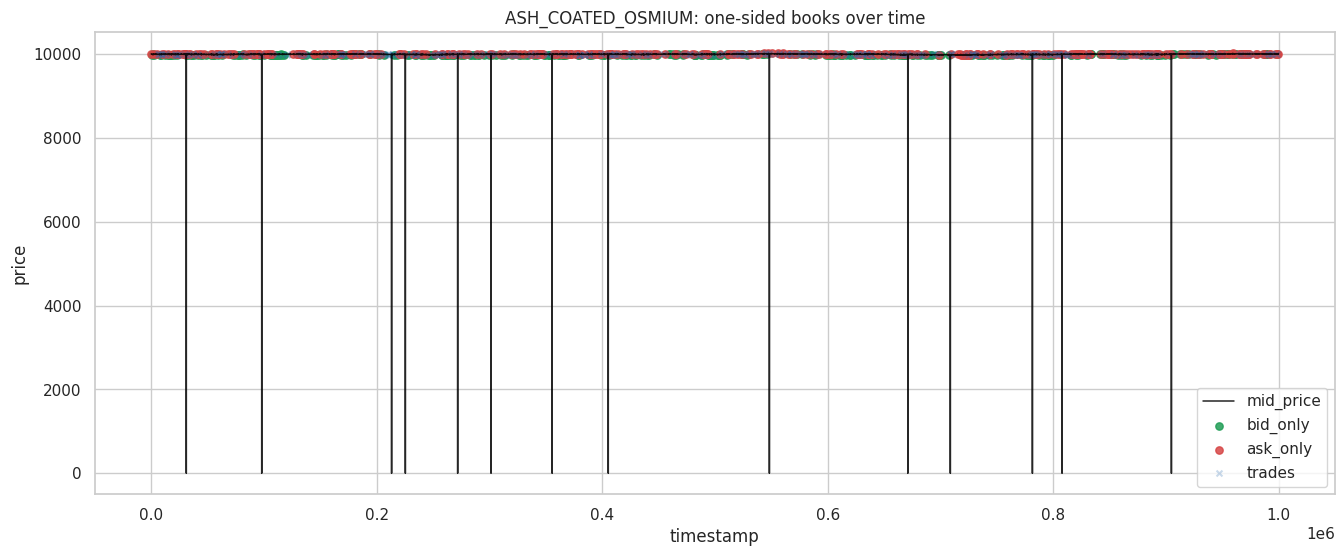

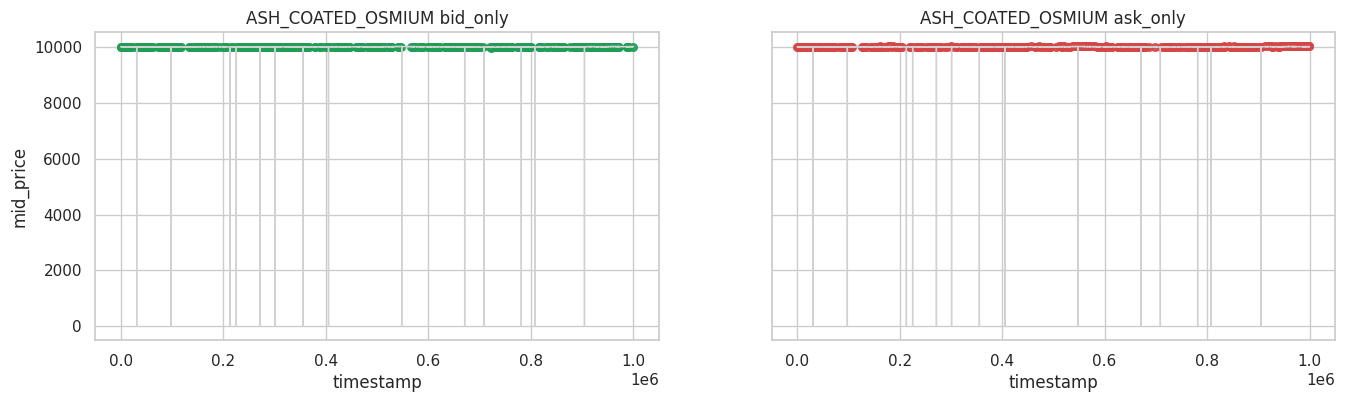

,book_state,count,first_timestamp,last_timestamp,avg_mid
0,ask_only,379,0,999800,10009.472296
1,bid_only,375,1100,998900,9993.306667


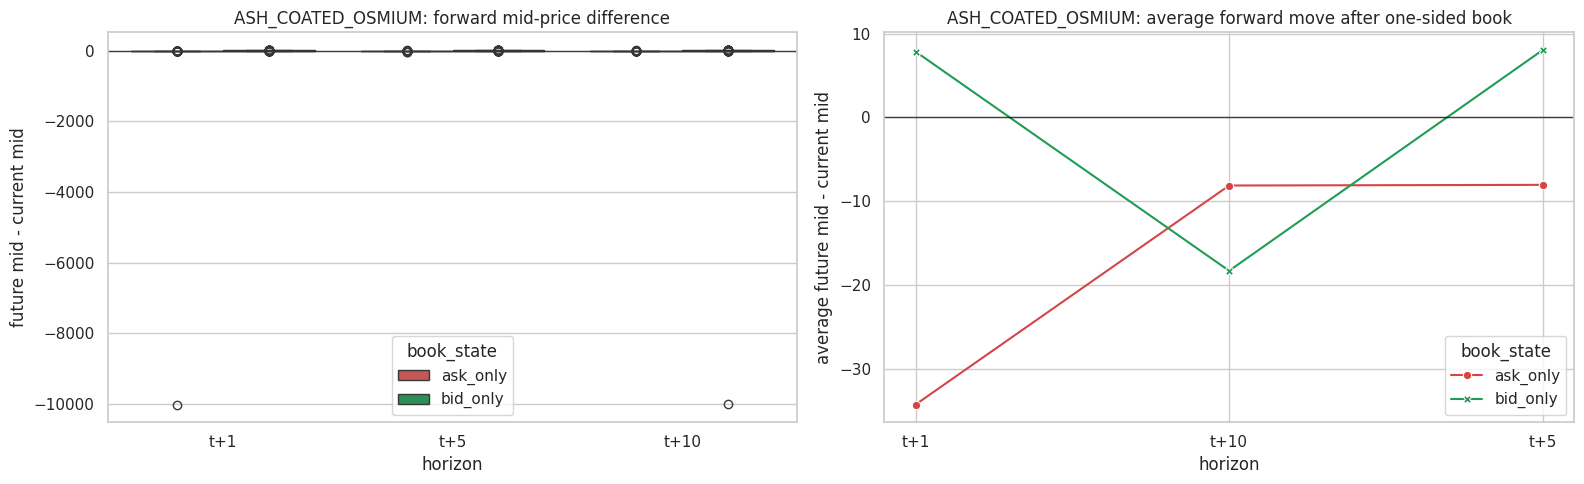

mid_diff_t1        mid_diff_t5        mid_diff_t10       
                  mean median        mean median         mean median
book_state                                                          
ask_only       -34.263   -8.0      -8.056   -8.0       -8.134   -8.0
bid_only         7.840    8.0       8.027    8.0      -18.305    8.0

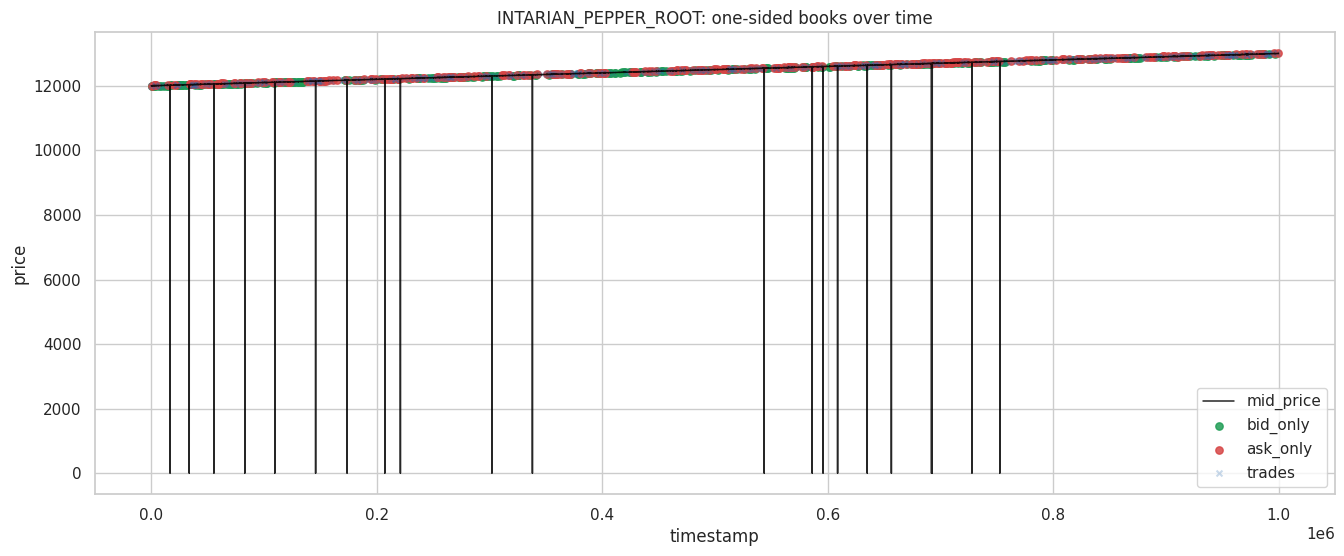

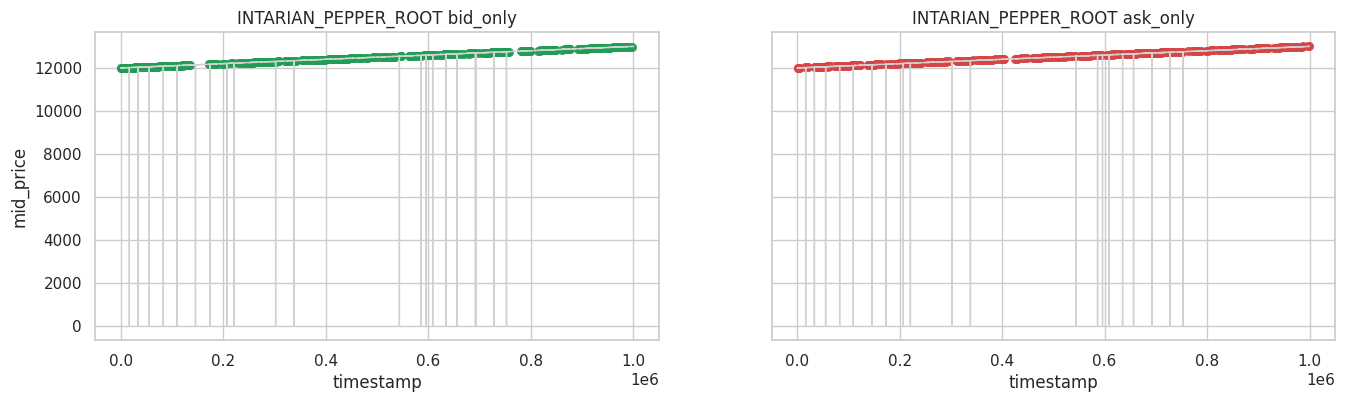

,book_state,count,first_timestamp,last_timestamp,avg_mid
0,ask_only,367,1100,999800,12513.021798
1,bid_only,359,400,997200,12466.674095


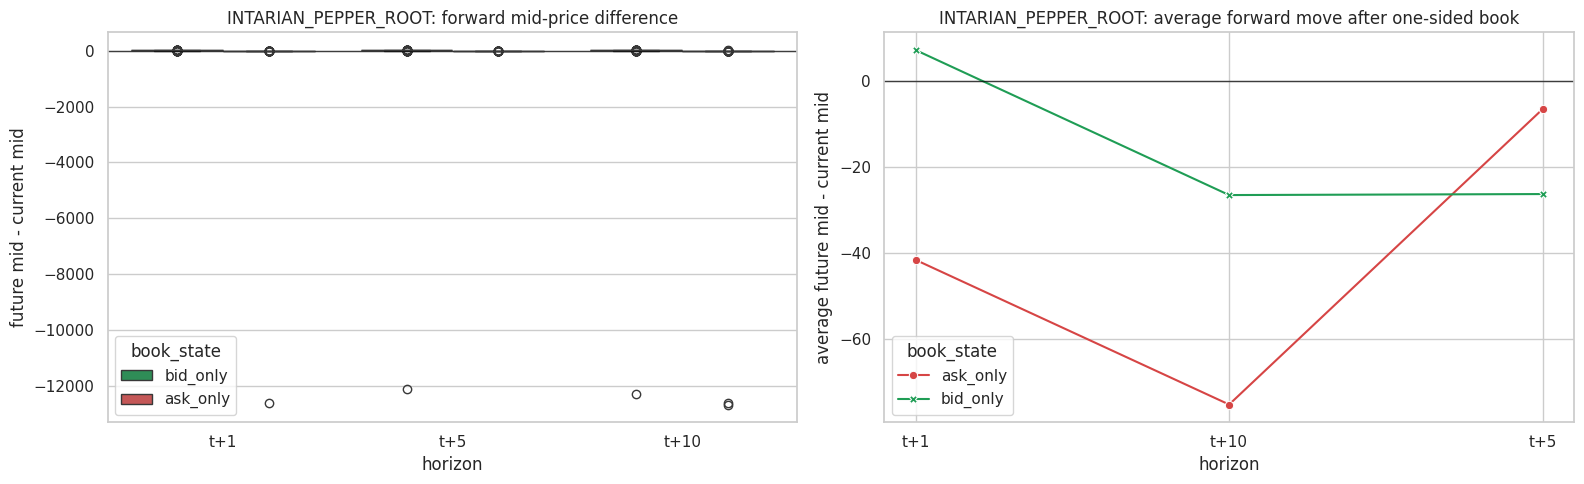

mid_diff_t1        mid_diff_t5        mid_diff_t10       
                  mean median        mean median         mean median
book_state                                                          
ask_only       -41.556   -7.0      -6.585   -6.5      -75.107   -6.0
bid_only         7.107    7.0     -26.291    7.5      -26.524    7.5

In [6]:
for product in prices["product"].unique():
    plot_one_sided_books(product)
    plot_forward_mid_differences(product)